In [1]:
!wget https://raw.githubusercontent.com/VincentCCL/MTAT/refs/heads/main/code/finetune_pretrained_mbart.py
!wget https://raw.githubusercontent.com/VincentCCL/MTAT/refs/heads/main/code/plot_train_val_new.py
!wget https://raw.githubusercontent.com/VincentCCL/MTAT/refs/heads/main/code/mbart_translate.py
!pip -q install evaluate sacrebleu

--2026-03-04 17:21:05--  https://raw.githubusercontent.com/VincentCCL/MTAT/refs/heads/main/code/finetune_pretrained_mbart.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14573 (14K) [text/plain]
Saving to: ‘finetune_pretrained_mbart.py’

finetune_pretrained 100%[===================>]  14.23K  --.-KB/s    in 0s      

2026-03-04 17:21:05 (28.5 MB/s) - ‘finetune_pretrained_mbart.py’ saved [14573/14573]

--2026-03-04 17:21:05--  https://raw.githubusercontent.com/VincentCCL/MTAT/refs/heads/main/code/plot_train_val_new.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent

In [2]:
!python finetune_pretrained_mbart.py \
  --src-file /kaggle/input/datasets/vincentvandeghinste/tatoeba-en-nl/train.en \
  --tgt-file /kaggle/input/datasets/vincentvandeghinste/tatoeba-en-nl/train.nl \
  --src-val /kaggle/input/datasets/vincentvandeghinste/tatoeba-en-nl/dev.en \
  --tgt-val /kaggle/input/datasets/vincentvandeghinste/tatoeba-en-nl/dev.nl \
  --src-lang en_XX \
  --tgt-lang nl_XX \
  --epochs 10 --batch-size 8 --lr 5e-5 \
  --save mbart_en_nl \
  --eval-metrics --history-json mbart.hist \
  --show-val-examples 5 \
  --max-src-len 128 --max-tgt-len 128 \
  --num-beams 4 --max-gen-len 128 \
  --save-total-limit 1

config.json: 1.43kB [00:00, 4.31MB/s]
tokenizer_config.json: 100%|███████████████████| 529/529 [00:00<00:00, 3.05MB/s]
sentencepiece.bpe.model: 100%|█████████████| 5.07M/5.07M [00:00<00:00, 7.25MB/s]
special_tokens_map.json: 100%|█████████████████| 649/649 [00:00<00:00, 3.46MB/s]
model.safetensors: 100%|████████████████████| 2.44G/2.44G [00:05<00:00, 417MB/s]
Loading weights: 100%|█| 516/516 [00:00<00:00, 2132.52it/s, Materializing param=
generation_config.json: 100%|██████████████████| 261/261 [00:00<00:00, 1.38MB/s]
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
Model device: cuda:0
  0%|                                                 | 0/48370 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
{'loss': '1.738', 'grad_norm': '11.86', 'learning_rate': '4.995e-0

In [3]:
!python mbart_translate.py \
  --model-dir mbart_en_nl \
  --src-file /kaggle/input/datasets/vincentvandeghinste/tatoeba-en-nl/test.en \
  --ref-file /kaggle/input/datasets/vincentvandeghinste/tatoeba-en-nl/test.nl \
  --out-file test.hyp.nl \
  --src-lang en_XX \
  --tgt-lang nl_XX \
  --num-beams 4 \
  --max-gen-len 128 \
  --metrics bleu,chrf

Loading weights: 100%|█| 516/516 [00:00<00:00, 2041.74it/s, Materializing param=
Wrote 1000 translations to test.hyp.nl
BLEU: 55.02
 signature: nrefs:1|case:mixed|eff:no|tok:13a|smooth:exp|version:2.6.0
chrF: 72.19
 signature: nrefs:1|case:mixed|eff:yes|nc:6|nw:0|space:no|version:2.6.0


Saved plot to mbart_train_val.png


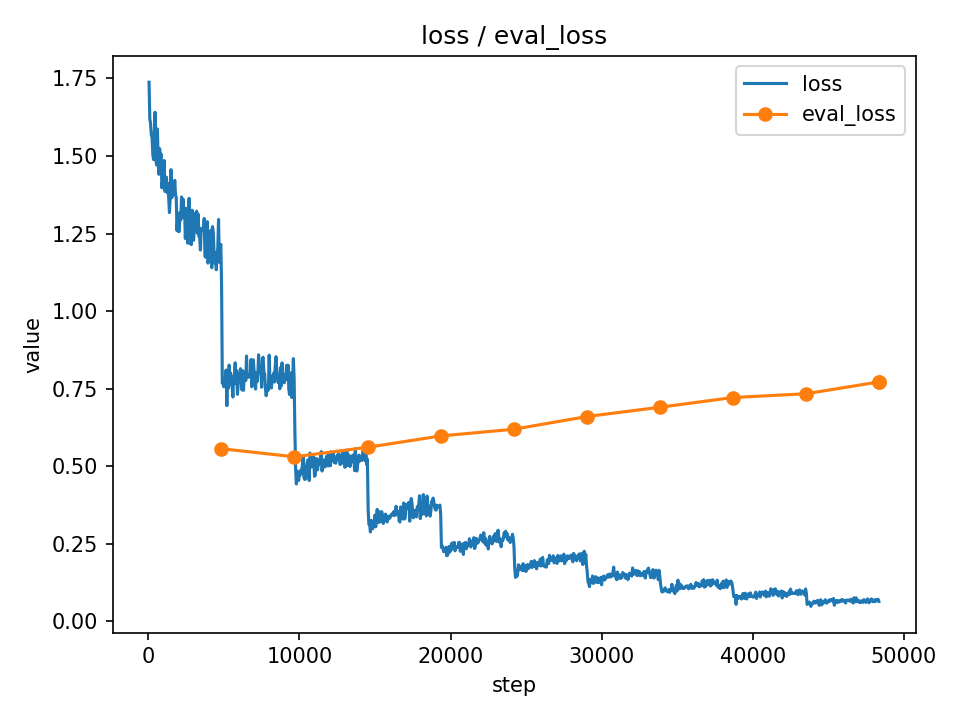

In [4]:
from IPython.display import Image, display
!python plot_train_val_new.py mbart.hist --train-key loss --val-key eval_loss --save mbart_train_val.png

display(Image(filename="mbart_train_val.png"))

